## Install Dependencies

In [27]:
import json
import numpy as np
import os
from pprint import pprint
from statistics import mean, stdev
from typing import List, Dict, Callable

In [28]:
%pip install matplotlib
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 100 # TODO: Change DPI before submitting paper.


[notice] A new release of pip is available: 25.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [29]:
%pip install pandas
import pandas as pd


[notice] A new release of pip is available: 25.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Util functions

In [30]:
def load_json(path: str) -> Dict:
    with open(path, "r") as json_file:
        return json.load(json_file)

In [31]:
def printb(text: str) -> None:
    print("\033[1m" + text + "\033[0m")

In [32]:
from dataclasses import dataclass

@dataclass
class Experiment:
    qubit_num: int
    gate_count: int
    target: str

    population_size: int
    max_generations: int
    mutation_prob: float
    crossover_prob: float
    selection_strategy: str

    cache_rebuild_frequency: int
    cache_size: int
    merging_rounds: int

    source_paths: List[str]
    seeds: List[int]

    tag: str
    label: str

    data_per_seed: List[pd.DataFrame]

    fitness_scores: pd.DataFrame
    redundancies: pd.DataFrame
    simulation_durations: pd.DataFrame
    cache_utilizations: pd.DataFrame

    def __hash__(self) -> str:
        key = f"{self.qubit_num}q{self.gate_count}g{self.target}st"
        key += f"{self.population_size}p{self.max_generations}mg{self.mutation_prob}mp"
        key += f"{self.crossover_prob}cp{self.selection_strategy}s"
        key += f"{self.cache_rebuild_frequency}crf{self.cache_size}cs{self.merging_rounds}mr"
        key += f"{self.tag}t"
        return hash(key)
    
    def __eq__(self, value: "Experiment"):
        return self.__hash__() == value.__hash__()


In [33]:
# Filter experiments

def filter_experiments(experiments: List[Experiment], filter_params: Dict, sort_by: str = "qubit_num") -> List:

    filtered_experiments: List[Experiment] = []
    for experiment in experiments:

        for key, value in filter_params.items():
            
            if experiment.__dict__[key] != value:
                break 

        else:
            filtered_experiments.append(experiment)                 


    filtered_experiments.sort(key=lambda item: item.__dict__[sort_by])
    return filtered_experiments

In [34]:
def merge_fitness_dfs(dfs: List[pd.DataFrame]) -> pd.DataFrame:
    total_df = pd.concat(dfs)

    avg_best = total_df.groupby("generation")["fitness_#0"].mean()
    median_best = total_df.groupby("generation")["fitness_#0"].median()
    std_best = total_df.groupby("generation")["fitness_#0"].std()

    merged_df = pd.concat([avg_best, median_best, std_best], keys=[
                          "avg_best_fitness", "median_best_fitness", "std_best_fitness"], axis=1)
    merged_df = merged_df.reset_index()
    merged_df.fillna(0, inplace=True)

    return merged_df

In [35]:
def merge_redundancy_dfs(dfs: List[pd.DataFrame]) -> pd.DataFrame:
    total_df = pd.concat(dfs)

    avg_redundancy = total_df.groupby("generation")["population_redundancy"].mean()
    median_redundancy = total_df.groupby("generation")["population_redundancy"].median()
    std_redundancy = total_df.groupby("generation")["population_redundancy"].std()

    merged_df = pd.concat([avg_redundancy, median_redundancy, std_redundancy], keys=[
                          "avg_redundancy", "median_redundancy", "std_redundancy"], axis=1)
    merged_df = merged_df.reset_index()
    merged_df.fillna(0, inplace=True)

    return merged_df

In [36]:
def merge_simulation_dfs(dfs: List[pd.DataFrame]) -> pd.DataFrame:
    total_df = pd.concat(dfs)

    avg_build_cache_duration = total_df.groupby(
        "generation")["build_cache_duration"].mean()
    median_build_cache_duration = total_df.groupby(
        "generation")["build_cache_duration"].median()
    std_build_cache_duration = total_df.groupby(
        "generation")["build_cache_duration"].std()

    avg_simulate_duration = total_df.groupby(
        "generation")["simulate_duration"].mean()
    median_simulate_duration = total_df.groupby(
        "generation")["simulate_duration"].median()
    std_simulate_duration = total_df.groupby(
        "generation")["simulate_duration"].std()

    merged_df = pd.concat([avg_build_cache_duration, median_build_cache_duration, std_build_cache_duration, avg_simulate_duration, median_simulate_duration, std_simulate_duration], keys=[
                          "avg_build_cache_duration", "median_build_cache_duration", "std_build_cache_duration", "avg_simulate_duration", "median_simulate_duration", "std_simulate_duration"], axis=1)
    merged_df = merged_df.reset_index()
    merged_df.fillna(0, inplace=True)

    return merged_df

In [37]:
def merge_cache_utilization_dfs(dfs: List[pd.DataFrame]) -> pd.DataFrame:
    total_df = pd.concat(dfs)

    avg_cache_hits = total_df.groupby(
        "generation")["cache_hits"].mean()
    median_cache_hits = total_df.groupby(
        "generation")["cache_hits"].median()
    std_cache_hits = total_df.groupby(
        "generation")["cache_hits"].std()

    avg_bigram_hit_count = total_df.groupby(
        "generation")["bigram_hit_count"].mean()
    median_bigram_hit_count = total_df.groupby(
        "generation")["bigram_hit_count"].median()
    std_bigram_hit_count = total_df.groupby(
        "generation")["bigram_hit_count"].std()

    avg_cache_hit_length = total_df.groupby(
        "generation")["average_cache_hit_length"].mean()
    median_cache_hit_length = total_df.groupby(
        "generation")["average_cache_hit_length"].median()
    std_cache_hit_length = total_df.groupby(
        "generation")["average_cache_hit_length"].std()

    merged_df = pd.concat([avg_cache_hits, median_cache_hits, std_cache_hits, avg_bigram_hit_count, median_bigram_hit_count, std_bigram_hit_count, avg_cache_hit_length, median_cache_hit_length, std_cache_hit_length], keys=[
                          "avg_cache_hits", "median_cache_hits", "std_cache_hits", "avg_bigram_hit_count", "median_bigram_hit_count", "std_bigram_hit_count", "avg_cache_hit_length", "median_cache_hit_length", "std_cache_hit_length"], axis=1)
    merged_df = merged_df.reset_index()
    merged_df.fillna(0, inplace=True)

    return merged_df

In [38]:
def default_label_function(config: Dict) -> str:
    return "TBD"

In [39]:
def load_experiments(results_dir: str = "results", tag: str = None, min_generations: int = None, label_function=default_label_function) -> List[Experiment]:
    experiments: Dict[str, Experiment] = {}

    for file_name in os.listdir(results_dir):
        if not file_name.endswith("_config.json"):
            continue

        config_path = f"{results_dir}/{file_name}"
        config = load_json(config_path)

        if tag is not None and config["tag"] != tag:
            continue

        data_path = f"{results_dir}/{file_name.replace('_config.json', '_results.csv')}"

        experiment_data = pd.read_csv(data_path, delimiter=";")
        for column in experiment_data.columns:
            experiment_data = experiment_data.rename(columns={
                column: column.strip().replace(" ", "_")
            })

        experiment = Experiment(
            qubit_num=config["qubit_num"],
            gate_count=config["gate_count"],
            target=config["target"],

            population_size=config["ga_params"]["population_size"],
            max_generations=config["ga_params"]["max_generations"],
            mutation_prob=config["ga_params"]["mutation_prob"],
            crossover_prob=config["ga_params"]["crossover_prob"],
            selection_strategy=config["ga_params"]["selection_strategy"],

            cache_rebuild_frequency=config["caching_params"]["cache_rebuild_frequency"],
            cache_size=config["caching_params"]["cache_size"],
            merging_rounds=config["caching_params"]["merging_rounds"],

            tag=None,  # TODO: Adjust once tag becomes part of config data.
            label=label_function(config),

            source_paths=[
                config_path
            ],

            seeds=[
                config["meta"]["seed"]
            ],

            data_per_seed=[experiment_data],

            fitness_scores=None,
            redundancies=None,
            simulation_durations=None,
            cache_utilizations=None
        )

        if experiment in experiments:
            experiments[experiment].source_paths.append(
                experiment.source_paths[0])
            experiments[experiment].seeds.append(experiment.seeds[0])
            experiments[experiment].data_per_seed.append(
                experiment.data_per_seed[0])
        else:
            experiments[experiment] = experiment

    experiments: List[Experiment] = list(experiments.values())
    for experiment in experiments:
        data_dfs = experiment.data_per_seed
        lengths = [len(df) for df in data_dfs]

        if min_generations is None:
            min_gen_threshold = max(lengths)
        else:
            min_gen_threshold = min_generations

        entries_to_pop = [
            i for i, length in enumerate(lengths) if length < min_gen_threshold
        ]

        for entry_to_pop in reversed(entries_to_pop):
            print(
                f"Excluding fitness of {experiment.source_paths[entry_to_pop]} due to length mismatch.")

            experiment.source_paths.pop(entry_to_pop)
            experiment.seeds.pop(entry_to_pop)
            experiment.data_per_seed.pop(entry_to_pop)

        experiment.fitness_scores = merge_fitness_dfs(
            experiment.data_per_seed)
        experiment.redundancies = merge_redundancy_dfs(
            experiment.data_per_seed)
        experiment.simulation_durations = merge_simulation_dfs(
            experiment.data_per_seed)
        experiment.cache_utilizations = merge_cache_utilization_dfs(
            experiment.data_per_seed)

    return experiments

## Visualization Functions

In [40]:
def plot_redundancy_per_generation(experiments: List[Experiment], target_path: str = None, plot_std: bool = False) -> None:
    ax = plt.subplot()

    for experiment in experiments:
        df = experiment.redundancies

        ax.plot(df["generation"], df["avg_redundancy"], label=experiment.label, linewidth=1)

        if plot_std:
            lower_bound = df["avg_redundancy"] - df["std_redundancy"]
            upper_bound = df["avg_redundancy"] + df["std_redundancy"]
            ax.fill_between(
                df["generation"], lower_bound, upper_bound, alpha=0.2
            )

    ax.set_ylim(0)

    ax.set_xlabel("generation")

    ax.set_ylabel("population redundancy")

    plt.grid()
    plt.legend()

    if target_path is not None:
        plt.savefig(target_path, bbox_inches='tight')

    plt.show()
    plt.clf()

In [41]:
def plot_fitness_per_generation(experiments: List[Experiment], target_path: str = None, plot_std: bool = False) -> None:
    ax = plt.subplot()

    for experiment in experiments:
        df = experiment.fitness_scores

        ax.plot(df["generation"], df["avg_best_fitness"], label=experiment.label, linewidth=1)

        if plot_std:
            lower_bound = df["avg_best_fitness"] - df["std_best_fitness"]
            upper_bound = df["avg_best_fitness"] + df["std_best_fitness"]
            ax.fill_between(
                df["generation"], lower_bound, upper_bound, alpha=0.2
            )

    ax.set_ylim(0)

    ax.set_xlabel("generation")

    ax.set_ylabel("avg. best fitness")

    plt.grid()
    plt.legend()

    if target_path is not None:
        plt.savefig(target_path, bbox_inches='tight')
    
    plt.show()
    plt.clf()

In [42]:
def plot_net_simulation_time_per_generation(experiments: List[Experiment], target_path: str = None, plot_std: bool = False) -> None:
    ax = plt.subplot()

    for experiment in experiments:
        df = experiment.simulation_durations

        ax.plot(df["generation"], df["avg_simulate_duration"], label=experiment.label, linewidth=1)

        if plot_std:
            lower_bound = df["avg_simulate_duration"] - df["std_simulate_duration"]
            upper_bound = df["avg_simulate_duration"] + df["std_simulate_duration"]
            ax.fill_between(
                df["generation"], lower_bound, upper_bound, alpha=0.2
            )

    ax.set_ylim(0)

    ax.set_xlabel("generation")

    ax.set_ylabel("net simulate time (in sec.)")

    plt.grid()
    plt.legend()

    if target_path is not None:
        plt.savefig(target_path, bbox_inches='tight')
    
    plt.show()
    plt.clf() 

In [43]:
def plot_total_simulation_time_per_generation(experiments: List[Experiment], target_path: str = None, plot_std: bool = False) -> None:
    ax = plt.subplot()

    for experiment in experiments:
        df = experiment.simulation_durations

        ax.plot(df["generation"], df["avg_simulate_duration"] + df["avg_build_cache_duration"], label=experiment.label, linewidth=1)

        if plot_std:
            # TODO: Research if we can compute shared stdev like this.
            lower_bound = df["avg_simulate_duration"] + df["avg_build_cache_duration"] - (df["std_simulate_duration"] + df["std_build_cache_duration"])
            upper_bound = df["avg_simulate_duration"] + df["avg_build_cache_duration"] + (df["std_simulate_duration"] + df["std_build_cache_duration"])
            ax.fill_between(
                df["generation"], lower_bound, upper_bound, alpha=0.2
            )

    ax.set_ylim(0)

    ax.set_xlabel("generation")

    ax.set_ylabel("total simulate time (in sec.)")

    plt.grid()
    plt.legend()

    if target_path is not None:
        plt.savefig(target_path, bbox_inches='tight')
    
    plt.show()
    plt.clf()  

In [44]:
def plot_cummulative_simulation_time_per_generation(experiments: List[Experiment], target_path: str = None) -> None:
    
    ax = plt.subplot()

    for experiment in experiments:
        df = experiment.simulation_durations

        ax.plot(df["generation"], df["avg_simulate_duration"].cumsum() + df["avg_build_cache_duration"].cumsum(), label=experiment.label, linewidth=1)


    ax.set_ylim(0)

    ax.set_xlabel("generation")

    ax.set_ylabel("cummulative simulate time (in sec.)")

    plt.grid()
    plt.legend()

    if target_path is not None:
        plt.savefig(target_path, bbox_inches='tight')
    
    plt.show()
    plt.clf() 

In [45]:
def plot_cache_hits_per_generation(experiments: List[Experiment], target_path: str = None, plot_std: bool = False) -> None:
    ax = plt.subplot()

    for experiment in experiments:
        df = experiment.cache_utilizations

        ax.plot(df["generation"], df["avg_cache_hits"], label=experiment.label, linewidth=1)

        if plot_std:
            # TODO: Research if we can compute shared stdev like this.
            lower_bound = df["avg_cache_hits"] - df["std_cache_hits"]
            upper_bound = df["avg_cache_hits"] + df["std_cache_hits"]
            ax.fill_between(
                df["generation"], lower_bound, upper_bound, alpha=0.2
            )

    ax.set_ylim(0)

    ax.set_xlabel("generation")

    ax.set_ylabel("cache hits")

    plt.grid()
    plt.legend()

    if target_path is not None:
        plt.savefig(target_path, bbox_inches='tight')
    
    plt.show()
    plt.clf()  

In [46]:
def plot_cummulative_cache_hits_per_generation(experiments: List[Experiment], target_path: str = None) -> None:
    ax = plt.subplot()

    for experiment in experiments:
        df = experiment.cache_utilizations

        ax.plot(df["generation"], df["avg_cache_hits"].cumsum(), label=experiment.label, linewidth=1)

    ax.set_ylim(0)

    ax.set_xlabel("generation")

    ax.set_ylabel("cummulative cache hits")

    plt.grid()
    plt.legend()

    if target_path is not None:
        plt.savefig(target_path, bbox_inches='tight')
    
    plt.show()
    plt.clf()  

In [47]:
def plot_cache_hit_length_per_generation(experiments: List[Experiment], target_path: str = None, plot_std: bool = False) -> None:
    ax = plt.subplot()

    for experiment in experiments:
        df = experiment.cache_utilizations

        ax.plot(df["generation"], df["avg_cache_hit_length"], label=experiment.label, linewidth=1)

        if plot_std:
            lower_bound = df["avg_cache_hit_length"] - df["std_cache_hit_length"]
            upper_bound = df["avg_cache_hit_length"] + df["std_cache_hit_length"]
            ax.fill_between(
                df["generation"], lower_bound, upper_bound, alpha=0.2
            )

    ax.set_ylim(0)

    ax.set_xlabel("generation")

    ax.set_ylabel("avg. cache hit length")

    plt.grid()
    plt.legend()

    if target_path is not None:
        plt.savefig(target_path, bbox_inches='tight')
    
    plt.show()
    plt.clf()  

## RQ 1: Varying Cache Parameters

### RQ 1.1: Varying Rebuild Frequency

In [48]:
def rebuild_frequency_label(config: Dict) -> str:
    return f"every {config['caching_params']['cache_rebuild_frequency']} generations"

In [49]:
varying_rebuild_frequency_experiments = load_experiments(
    results_dir="results/varying_rebuild_frequency", min_generations=1000, label_function=rebuild_frequency_label)

varying_rebuild_frequency_experiments = filter_experiments(varying_rebuild_frequency_experiments, filter_params={}, sort_by="cache_rebuild_frequency")
print(
    f"Number of grid search experiments: {len(varying_rebuild_frequency_experiments)}")
print(
    f"Seed counts per config: {set([len(experiment.seeds) for experiment in varying_rebuild_frequency_experiments])}")

Number of grid search experiments: 5
Seed counts per config: {5}


Population redundancy per generation:


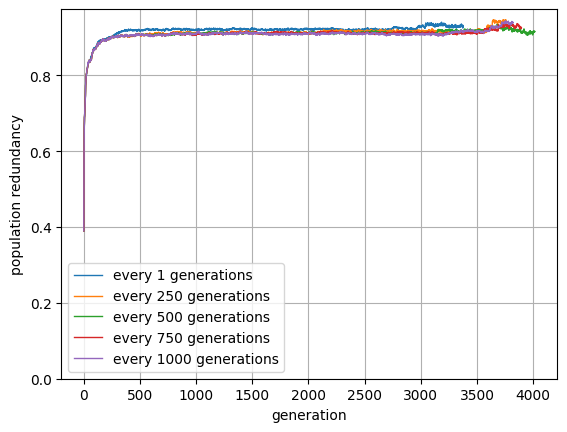

<Figure size 640x480 with 0 Axes>

In [50]:
printb("Population redundancy per generation:")
plot_redundancy_per_generation(varying_rebuild_frequency_experiments)

Best fitness per generation:


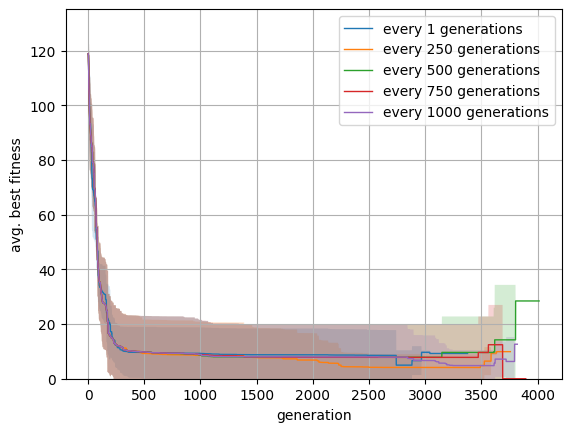

<Figure size 640x480 with 0 Axes>

In [51]:
printb("Best fitness per generation:")
plot_fitness_per_generation(varying_rebuild_frequency_experiments, plot_std=True)

Net simulation time per generation:


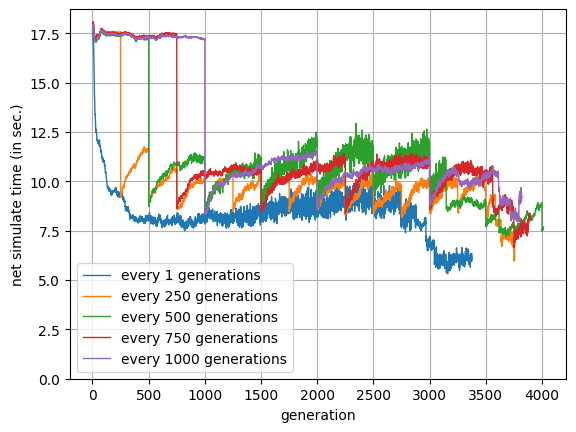

Total simulation time per generation:


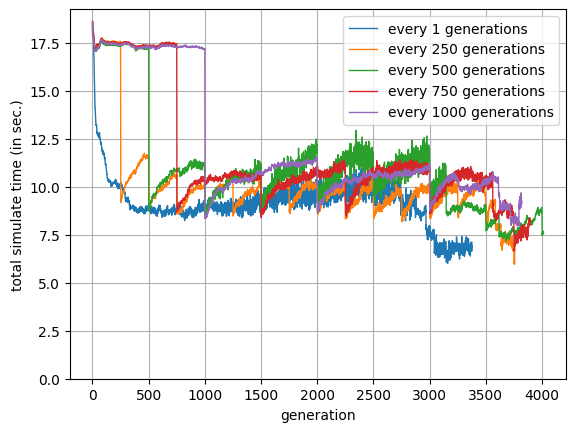

Cummulative simulation time per generation:


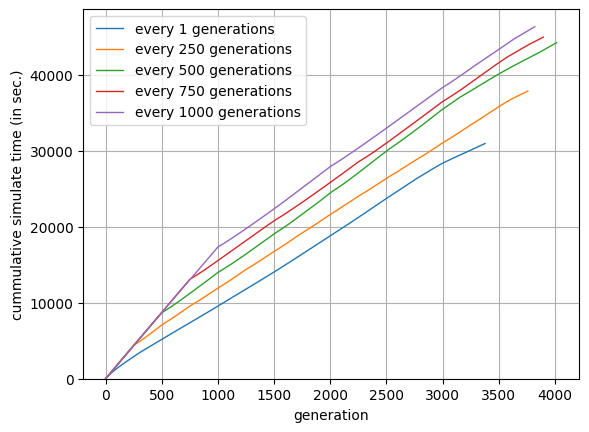

<Figure size 640x480 with 0 Axes>

In [52]:
printb("Net simulation time per generation:")
plot_net_simulation_time_per_generation(varying_rebuild_frequency_experiments, plot_std=False)

printb("Total simulation time per generation:")
plot_total_simulation_time_per_generation(varying_rebuild_frequency_experiments, plot_std=False)

printb("Cummulative simulation time per generation:")
plot_cummulative_simulation_time_per_generation(varying_rebuild_frequency_experiments)

Cache hits per generation:


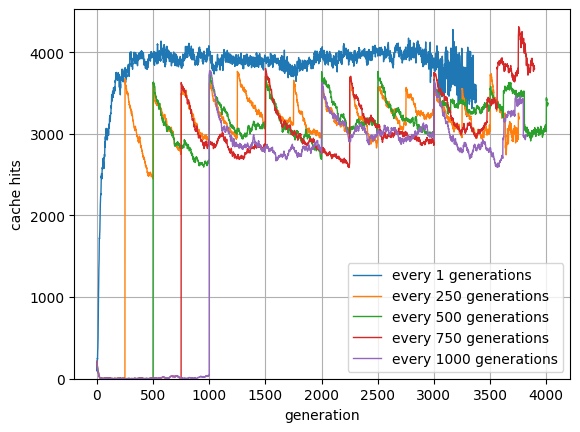

Cummulative cache hits per generation:


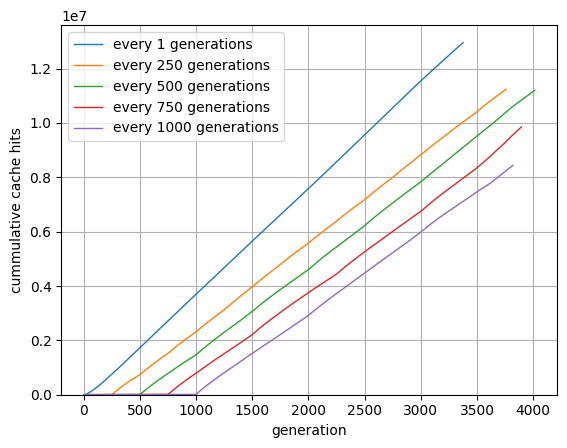

<Figure size 640x480 with 0 Axes>

In [53]:
printb("Cache hits per generation:")
plot_cache_hits_per_generation(varying_rebuild_frequency_experiments, plot_std=False)

printb("Cummulative cache hits per generation:")
plot_cummulative_cache_hits_per_generation(varying_rebuild_frequency_experiments)

Average cache hit length:


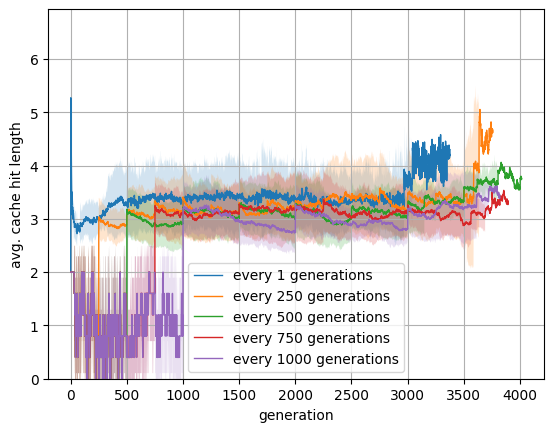

<Figure size 640x480 with 0 Axes>

In [54]:
printb("Average cache hit length:")
plot_cache_hit_length_per_generation(varying_rebuild_frequency_experiments, plot_std=True)